In [240]:
import pandas as pd
import numpy as np
import hist
import matplotlib as mpl
import mplhep
#import mplhep.error_estimation will come back to this later
mpl.style.use(mplhep.style.ROOT)
import matplotlib.pyplot as plt
import scipy
from scipy import optimize
from scipy.optimize import curve_fit
import yaml
from matplotlib import axes

In [3]:
import os
os.getcwd()

'/export/scratch/users/rodr1001/my_code/my_code/ldmx/hgcroc/pedestal_data/data'

In [223]:
pedestal = pd.read_csv('pedestal_20250725_174236.csv')

In [224]:
# define a unique ID for each channel to make histograms a bit easier to make
pedestal['uid'] = pedestal['i_link'].astype(str)+'_'+pedestal['channel']

In [225]:
#pedestal.head() - looking at updated csv

In [226]:
def fill_and_plot_all_channels(
    xname, xlabel, xmin, xmax, rebin=1
):
    plt.figure(figsize=(20,10))
    (
        hist.Hist.new
        .StrCategory(pedestal['uid'].unique(), label='Link_Channel')
        .Reg((xmax-xmin)//rebin,xmin,xmax, label=xlabel)
        .Double()
    ).fill(
        pedestal['uid'],
        pedestal[xname]
    ).plot2d(
        cmin=1,
        cbarsize=0.7
    )
    plt.xticks(rotation=90, size='x-small')
    plt.show()

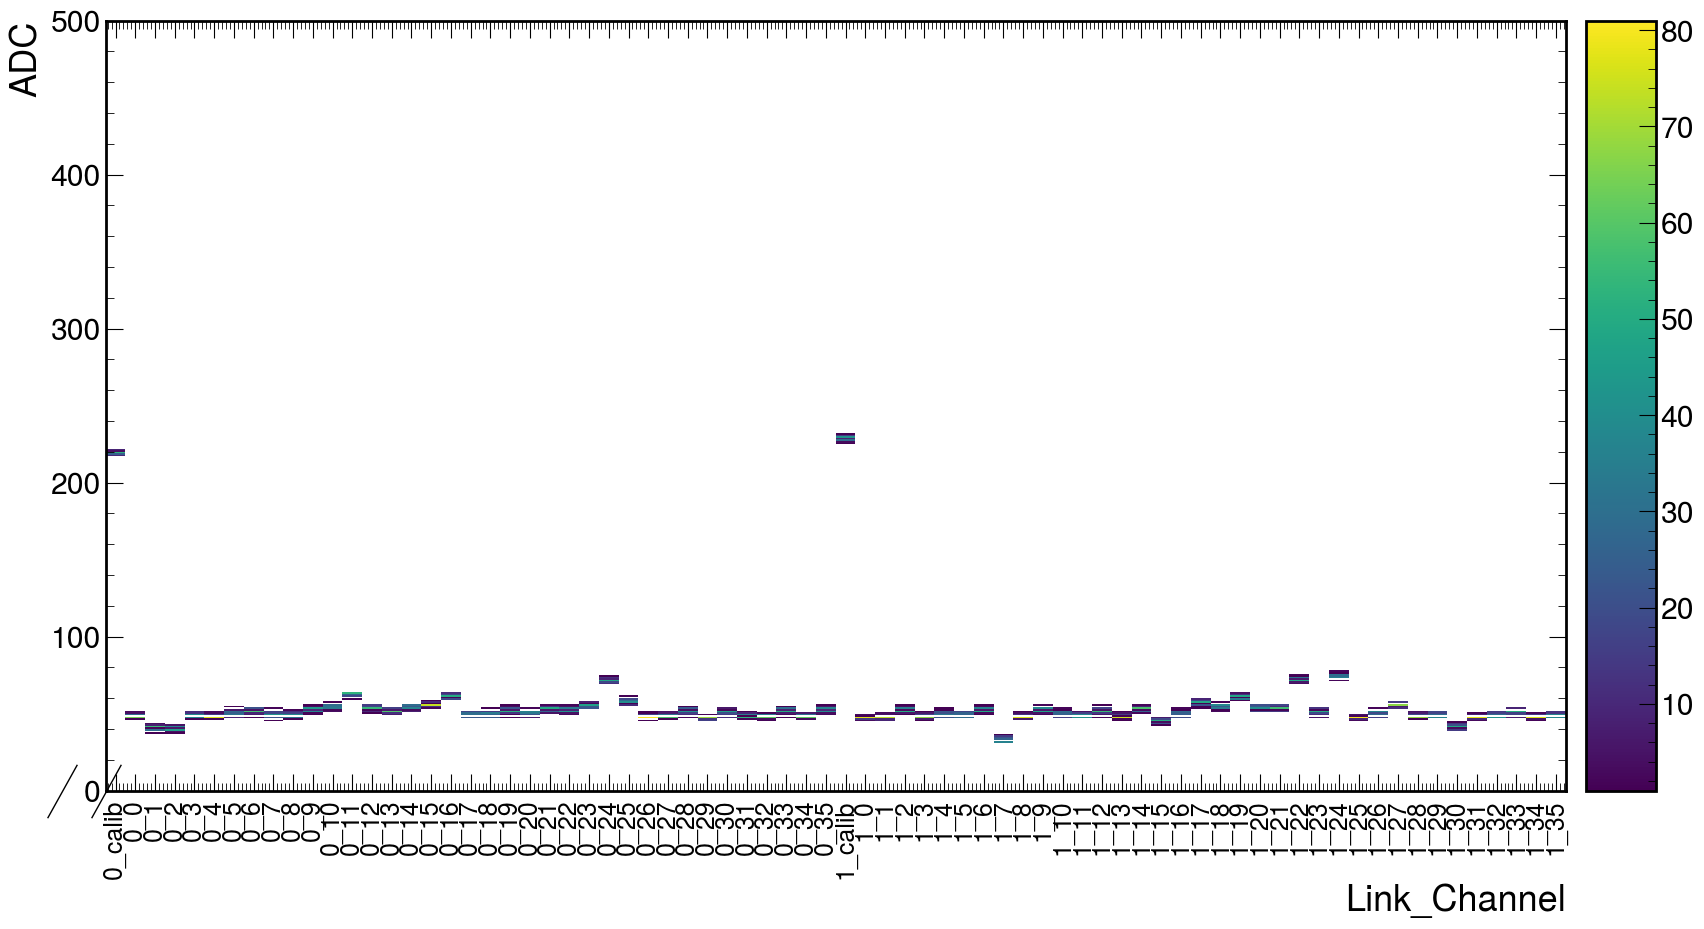

In [227]:
#general ADC Plot
fill_and_plot_all_channels('adc','ADC',0,500)

In [228]:
link_0 = pedestal[pedestal['i_link'] ==0] # separated the pedestal run by the two link channels - the two halves seen in HGCROC Tuning slides
link_1 = pedestal[pedestal['i_link'] ==1]
link_0_norm =link_0[link_0['channel'] != 'calib'] # removed the calibration channels to assess means/medians
link_1_norm =link_1[link_1['channel'] != 'calib']

Text(0.5, 1.0, 'Link 0')

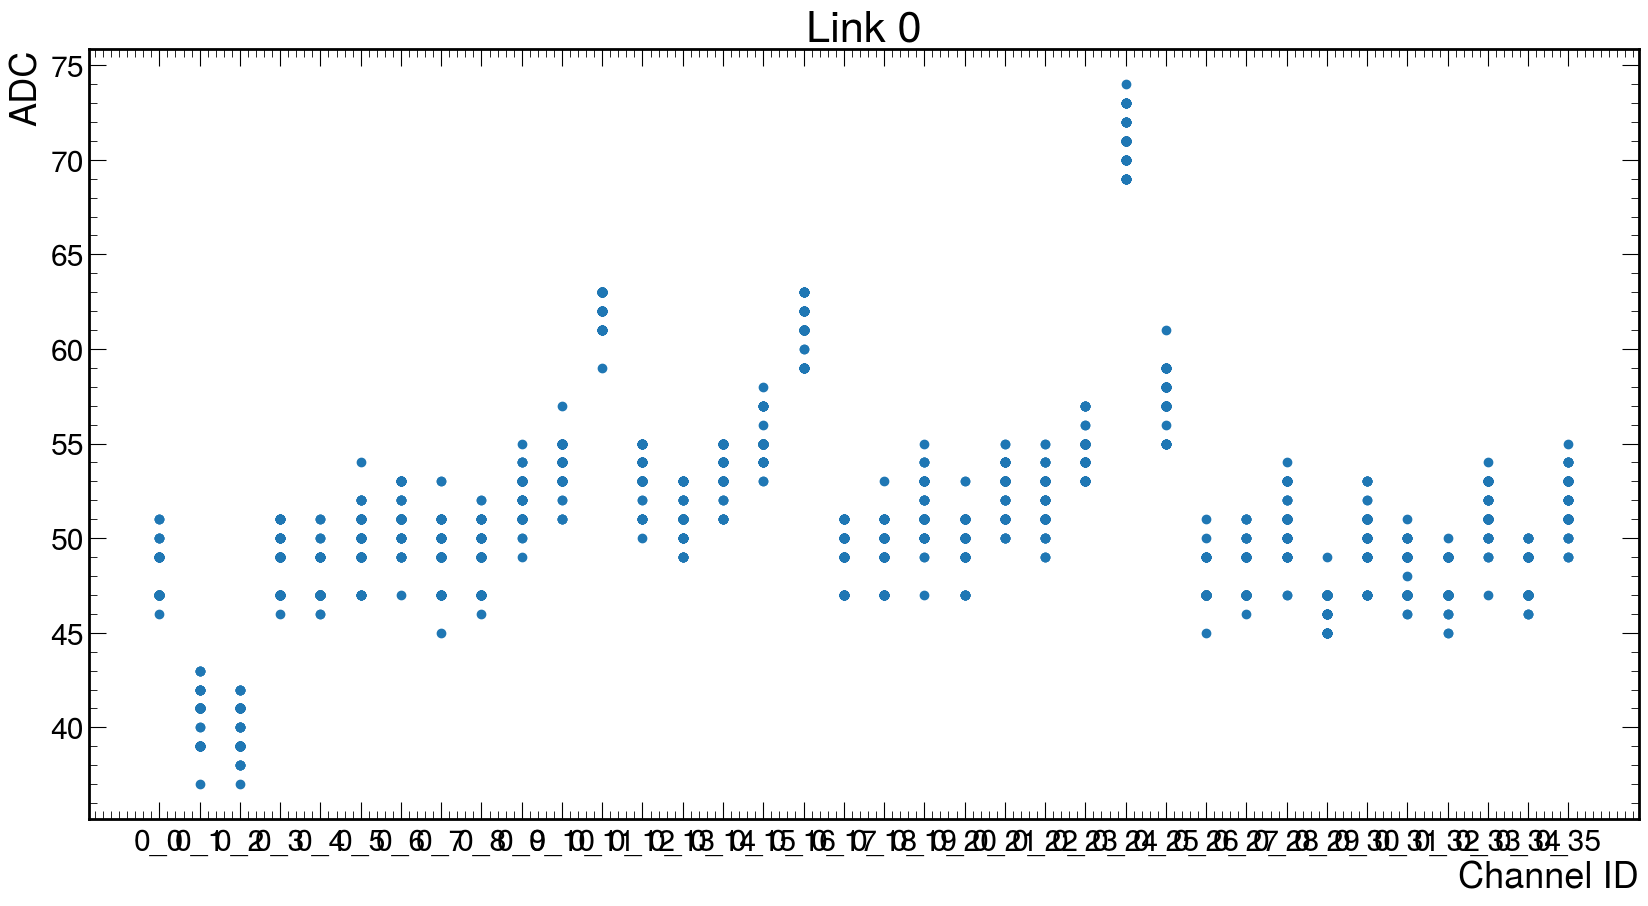

In [229]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [230]:
print ("Link 0 median ADC is " + str(link_0_norm['adc'].median()) + " without calibration channels")
print ("Link 0 mean ADC is " + str(link_0_norm['adc'].mean()) + " without calibration channels")



Link 0 median ADC is 51.0 without calibration channels
Link 0 mean ADC is 51.18472222222222 without calibration channels


Text(0.5, 1.0, 'Link 0')

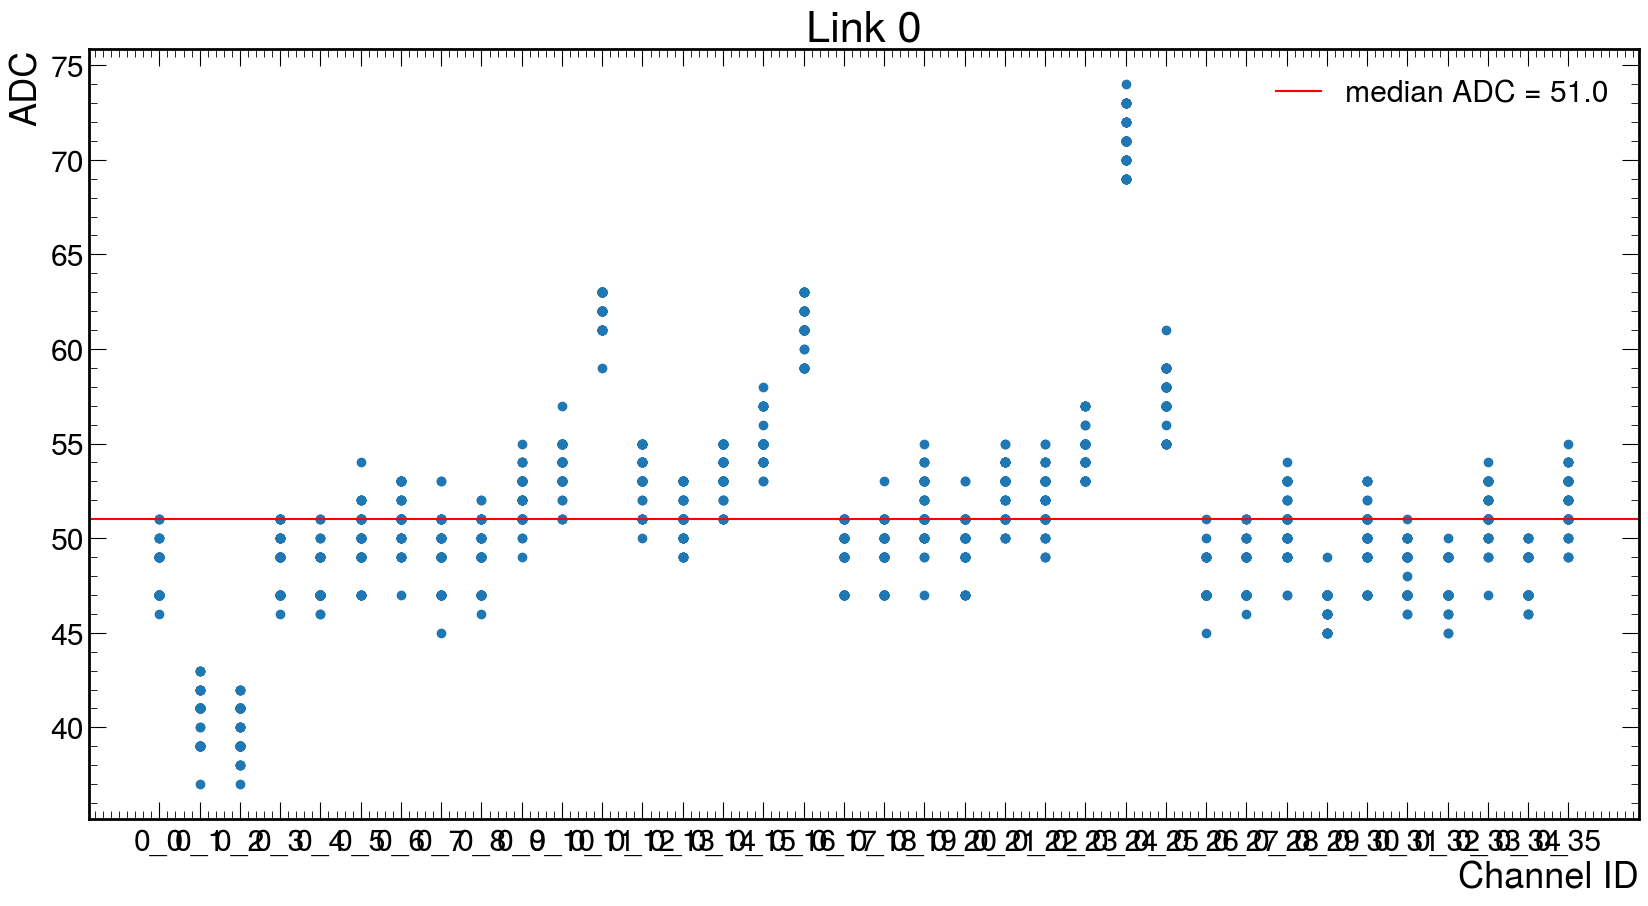

In [231]:
plt.figure(figsize=(20,10))
plt.scatter(link_0_norm.uid,link_0_norm.adc)
plt.axhline(y=(link_0_norm['adc'].median()), color='r', label = "median ADC = " + str(link_0_norm['adc'].median()) )
#plt.axhline(y = 209.5, color = 'g', label = " default median ADC = 209.5")
#plt.axhline(y = 50, color = 'r', label = " new median ADC = 50")
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0")

In [232]:
print ("Link 1 median ADC is " + str(link_1_norm['adc'].median()) + " without calibration channels")
print ("Link 1 mean ADC is " + str(link_1_norm['adc'].mean()) + " without calibration channels")


Link 1 median ADC is 50.0 without calibration channels
Link 1 mean ADC is 50.67166666666667 without calibration channels


Text(0.5, 1.0, 'Link 1')

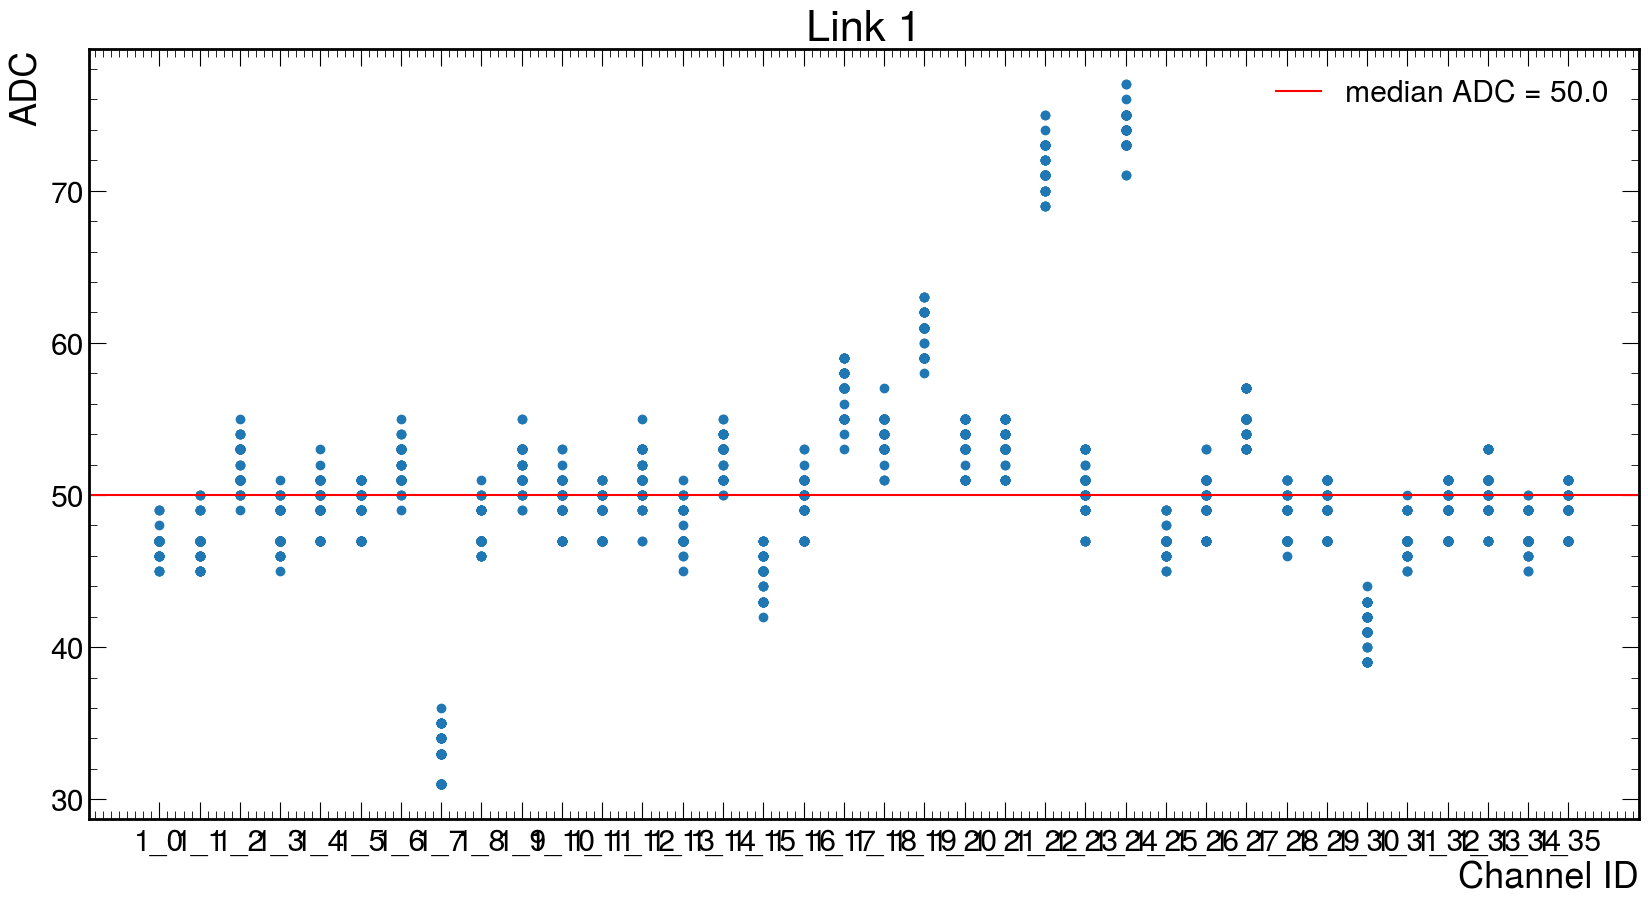

In [233]:
plt.figure(figsize=(20,10))
plt.scatter(link_1_norm.uid,link_1_norm.adc)
plt.axhline(y=(link_1_norm['adc'].median()), color='r', label = "median ADC = " + str(link_1_norm['adc'].median()) )
#plt.axhline(y = 207.0, color = 'g', label = "default median ADC = 207.0 " )
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1")

Text(0.5, 1.0, 'Link 0 channel median -leveled to 50')

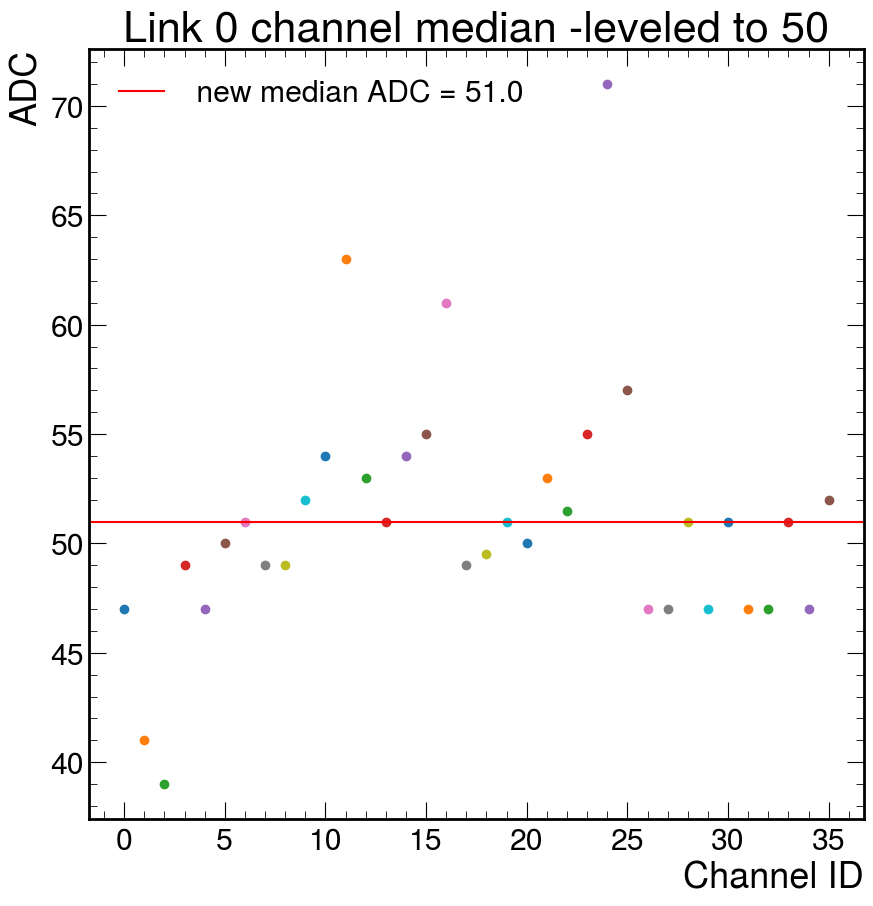

In [236]:
l0_ch_med = [] #the median ADC of each channel, in order from 0 to 35
l0_ch_stddev = []
for i in range(36):
    median = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].median()
    #ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l0_ch_med.append(median)
    #l0_ch_stddev.append(ch_stddev)
link_0_median= np.median(l0_ch_med) #median of the median ADC list
#plt.axhline(y = 209.5, color = 'g', label = " default median ADC = 209.5")
plt.axhline(y = link_0_median, color = 'r', label = " new median ADC = "+str(link_0_median))
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 0 channel median -leveled to 50")
#plt.savefig("Link0_inv_vref_50")


Text(0.5, 1.0, 'Link 1 channel median - level to 50')

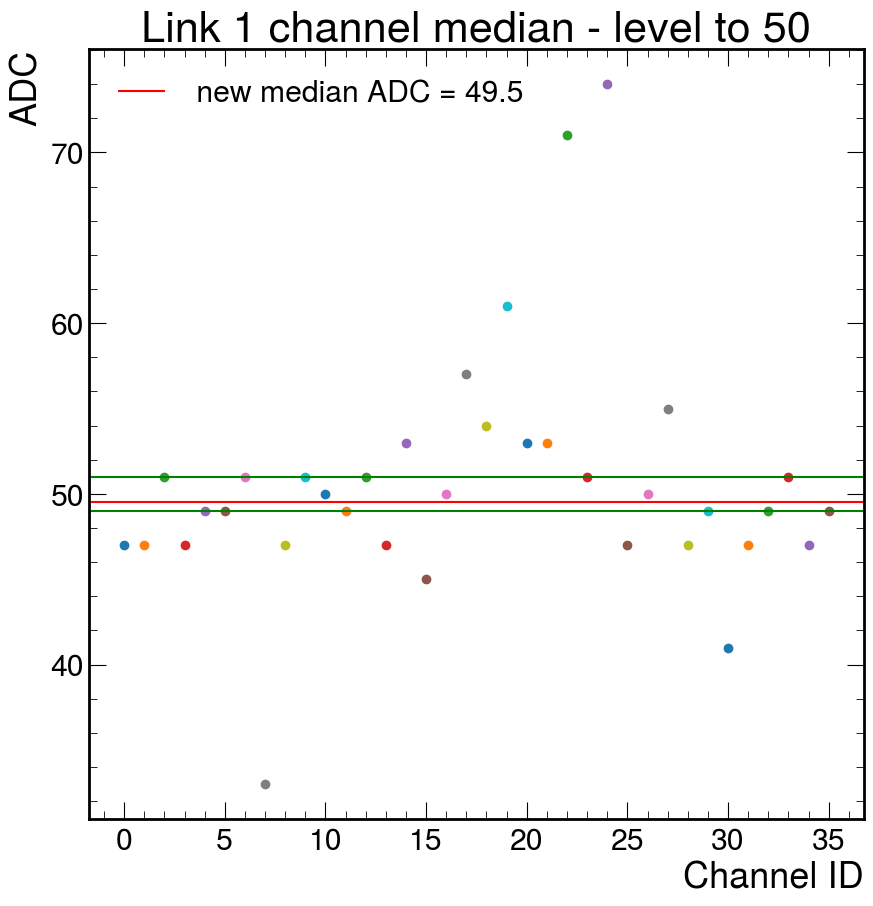

In [243]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l0_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #ch_stddev = link_0_norm[link_0_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l0_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
plt.axhline(y = 49, color = 'g')
plt.axhline(y = 51, color = 'g')
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+str(link_1_median))

plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median - level to 50")
#plt.savefig("Link0_inv_vref_50")


Text(0.5, 1.0, 'Link 1 channel median')

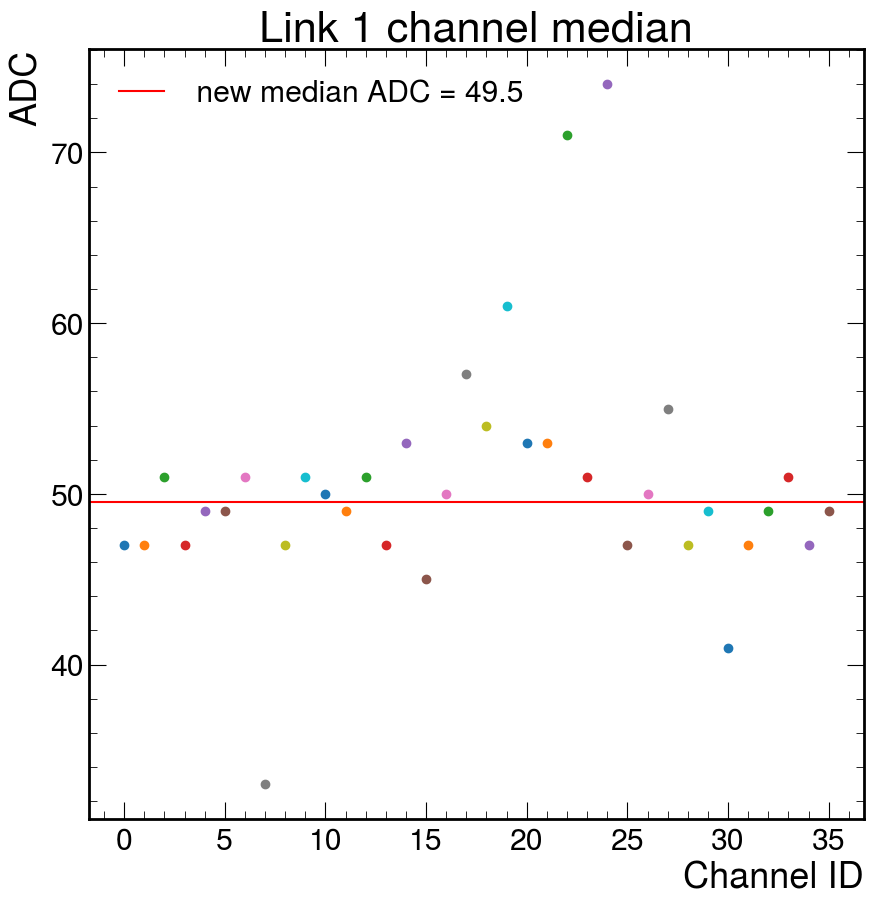

In [209]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l1_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #if median <= 207:
        #print("CH_"+str(i)+ " has median lower than 207")
    #ch_stddev = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l1_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
#plt.axhline(y = 207.0, color = 'g', label = "default median ADC = 207.0")
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+ str(link_1_median))
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")
#plt.savefig("Link_1_inv_vref_50")

Text(0.5, 1.0, 'Link 1 channel median')

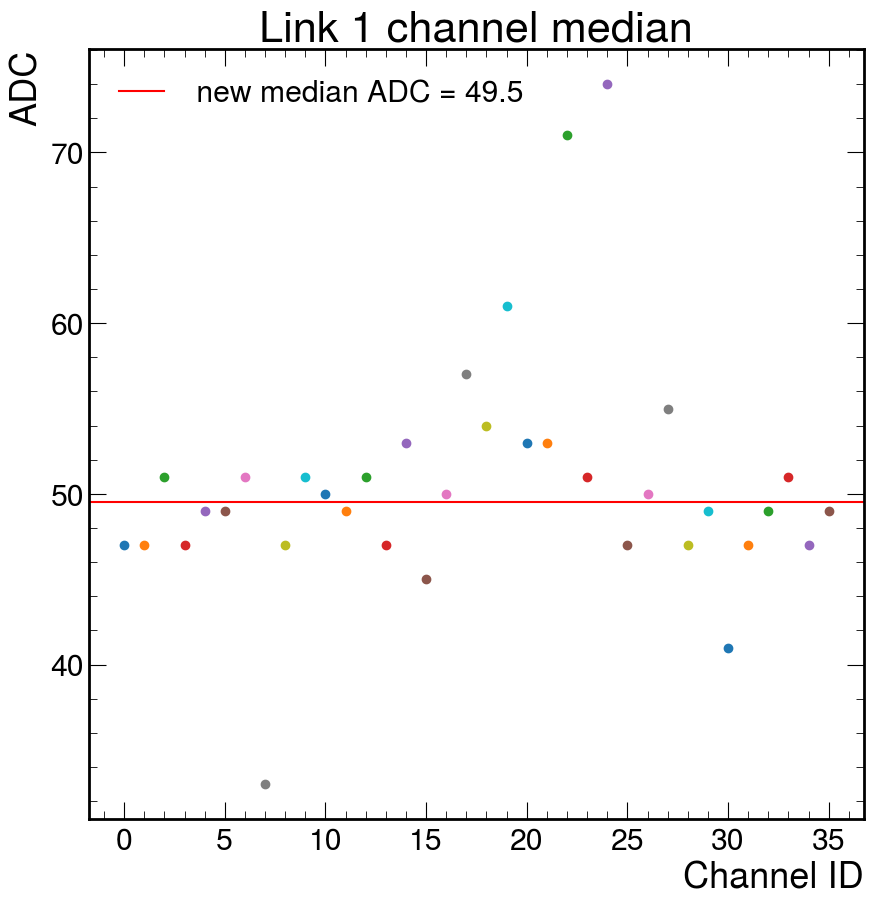

In [156]:
l1_ch_med = [] #the median ADC of each channel, in order from 0 to 35
#l1_ch_stddev = []
for i in range(36):
    median = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].median()
    #if median <= 207:
        #print("CH_"+str(i)+ " has median lower than 207")
    #ch_stddev = link_1_norm[link_1_norm['channel'] == str(i)]['adc'].std()

    plt.scatter(x = i, y = median )
    l1_ch_med.append(median)
    #l1_ch_stddev.append(ch_stddev)
link_1_median= np.median(l1_ch_med) #median of the median ADC list
#plt.axhline(y = 207.0, color = 'g', label = "default median ADC = 207.0")
plt.axhline(y = link_1_median, color = 'r', label = " new median ADC = "+ str(link_1_median))
plt.legend(loc="best")
plt.xlabel("Channel ID")
plt.ylabel("ADC")
plt.title("Link 1 channel median")
#plt.savefig("Link_1_inv_vref_50")